# NUDGE flagship — OCT4 vs NANOG: a resolved switch, and an honest abstention

**The question a linear screen can't answer.** Knock a pluripotency factor down by
varying amounts and watch a self-renewal signature fall. Does the response fall
**abruptly** past a threshold (an ultrasensitive *switch* — a **gain / `n`** call) or
**gradually** (a *graded* response)? And — the part that matters most — **when can't you
tell?**

NUDGE answers with the same `K` (threshold) / `n` (gain) / `v_max` (ceiling) vocabulary it
uses on single-cell distributions, here read from a **dose axis**. Single-cell bimodality
and bulk dose-response ultrasensitivity are *two measurements of one Hill circuit*.

This notebook tells a **two-part story** on one real dataset
([GSE283614](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE283614), Yao et al.
2025):

1. **OCT4 → `switch`.** A clean, resolved ultrasensitive call (`n ≈ 6.7`, R² = 0.99).
2. **NANOG → `unresolved`.** NUDGE *abstains* — and we prove, independently, that the data
   genuinely cannot resolve the gain. This is the fail-safe catching a classic human
   over-reading of an under-determined curve (`NUDGE-LIM-007`).

> **Honesty note, up front.** The fitted `n` is an **apparent population gain** with a
> confidence interval — *not* molecular cooperativity. Pseudobulk conflates within-cell
> cooperativity with a spread of single-cell thresholds.


In [1]:
%matplotlib inline
import os
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from nudge.inference.bridge import knockdown_dose_response
from nudge.inference.dose_response import attribute_dose_response, fit_dose_response

from nudge import warmup
warmup()  # pre-compile the JAX fit paths once, so the fits below run at full speed

# The converted ESC screen (raw counts + guide calls). Override with an env var if needed.
H5AD = os.environ.get("OCT4_NANOG_H5AD", "/media/nick/Seagate Hub/oct4_nanog/ESC.h5ad")
SIGNATURE = ["SOX2", "LIN28A", "UTF1", "DNMT3B", "TDGF1", "ZFP42", "SALL4"]  # self-renewal
TARGETS = {"OCT4": "POU5F1", "NANOG": "NANOG"}  # guide-group prefix -> gene knocked down

adata = ad.read_h5ad(H5AD)
present = [g for g in SIGNATURE if g in set(map(str, adata.var_names))]
print(f"cells: {adata.n_obs:,}   genes: {adata.n_vars:,}")
print("conditions:", dict(adata.obs['condition'].value_counts()))
print("self-renewal signature genes present:", present)


cells: 9,537   genes: 33,538
conditions: {'WT': np.int64(3773), 'OCT4': np.int64(2979), 'NANOG': np.int64(2785)}
self-renewal signature genes present: ['SOX2', 'LIN28A', 'UTF1', 'DNMT3B', 'TDGF1', 'ZFP42', 'SALL4']


## The dose axis is the guide axis

Each guide against a target achieves a **different knockdown strength**, so a panel of
guides *is* a dose series. `knockdown_dose_response` turns the screen into paired points:

- **dose** = fractional knockdown of the target gene = `1 − mean(target | guide) /
  mean(target | control)` (depth-normalized),
- **response** = the self-renewal signature relative to control.

In NUDGE's terms each guide is an **operating point** — and a *series* of operating points
is exactly what breaks the gain⇄threshold degeneracy a single snapshot can't.


In [2]:
points = {}
for label, gene in TARGETS.items():
    dose, resp = knockdown_dose_response(
        adata, target_gene=gene, signature=present, group_prefix=label,
        min_cells_per_group=15,
    )
    points[label] = (dose, resp)
    print(f"{label}: {len(dose)} guide-dose points | "
          f"knockdown spans [{dose.min():.2f}, {dose.max():.2f}] | "
          f"signature {resp[0]:.2f} -> {resp[-1]:.2f}")


OCT4: 16 guide-dose points | knockdown spans [0.01, 0.76] | signature 1.00 -> 0.41


NANOG: 17 guide-dose points | knockdown spans [0.08, 0.75] | signature 0.95 -> 0.69


## Part 1 — OCT4: a resolved ultrasensitive switch

The self-renewal signature stays flat while OCT4 is only mildly knocked down, then **drops
sharply** once knockdown passes ~50%. That sharp transition *inside* the measured range is
what makes the gain identifiable.


In [3]:
dose, resp = points["OCT4"]
res_oct4 = attribute_dose_response(dose, resp, direction="repress", n_boot=1000, seed=0)
f = res_oct4.fit
print(f"CALL: {res_oct4.call.upper()}")
print(f"apparent gain n = {f.n:.2f}  (95% CI {f.ci_n[0]:.2f}-{f.ci_n[1]:.2f})")
print(f"K (threshold)  = {f.k_threshold:.2f}   R2 = {f.r2:.3f}   "
      f"spans_inflection = {f.spans_inflection}")
print(f"ΔBIC(graded - switch) = {f.bic_graded - f.bic_switch:+.1f}")
print(f"\n{res_oct4.reason}")


CALL: SWITCH
apparent gain n = 6.74  (95% CI 4.70-12.00)
K (threshold)  = 0.65   R2 = 0.991   spans_inflection = True
ΔBIC(graded - switch) = +54.3

apparent gain n=6.74 (95% CI 4.70–12.00); CI clears the ultrasensitive line n>2 and free-n beats graded by ΔBIC=54.3 — ultrasensitive/switch-like (APPARENT population gain, not molecular cooperativity: pseudobulk conflates cooperativity with a spread of single-cell thresholds)


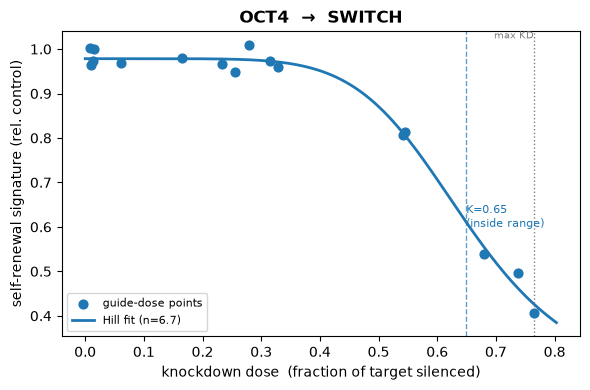

In [4]:
def hill_repress(d, floor, amp, K, n):
    return floor + amp * (K**n) / (K**n + np.maximum(d, 1e-9) ** n)

def plot_fit(ax, label, res, color):
    dose, resp = points[label]
    f = res.fit
    xs = np.linspace(0, max(dose.max(), f.k_threshold) * 1.05, 200)
    ax.scatter(dose, resp, s=40, color=color, zorder=3, label="guide-dose points")
    ax.plot(xs, hill_repress(xs, f.floor, f.amp, f.k_threshold, f.n), color=color,
            lw=2, label=f"Hill fit (n={f.n:.1f})")
    ax.axvline(dose.max(), ls=":", color="gray", lw=1)
    ax.axvline(f.k_threshold, ls="--", color=color, lw=1, alpha=0.7)
    ax.set_xlabel("knockdown dose  (fraction of target silenced)")
    ax.set_ylabel("self-renewal signature (rel. control)")
    ax.set_title(f"{label}  →  {res.call.upper()}", fontweight="bold")
    ax.legend(loc="lower left", fontsize=8)
    ax.annotate("max KD", (dose.max(), ax.get_ylim()[1]), fontsize=7,
                color="gray", ha="right", va="top")

fig, ax = plt.subplots(figsize=(6, 4))
plot_fit(ax, "OCT4", res_oct4, "C0")
ax.annotate(f"K={res_oct4.fit.k_threshold:.2f}\n(inside range)",
            (res_oct4.fit.k_threshold, 0.6), fontsize=8, color="C0")
plt.tight_layout(); plt.show()


## Part 2 — NANOG: NUDGE abstains (`unresolved`)

NANOG's knockdown reaches only ~75%, and the signature declines **shallowly** — it never
reaches a floor. The Hill fit puts the threshold `K` *past the last dose*, and the
bootstrap `n` CI blows up to the parameter ceiling. NUDGE returns **`unresolved`** rather
than guess.


CALL: UNRESOLVED
apparent gain n = 2.44  (95% CI 1.60-12.00)
K (threshold)  = 0.81   R2 = 0.735   spans_inflection = False   (dose max = 0.75)

K=0.806 lies outside the dose range [0.0773, 0.749] — the doses do not span the inflection, so a Hill fit sees only one arm and gain is unidentifiable


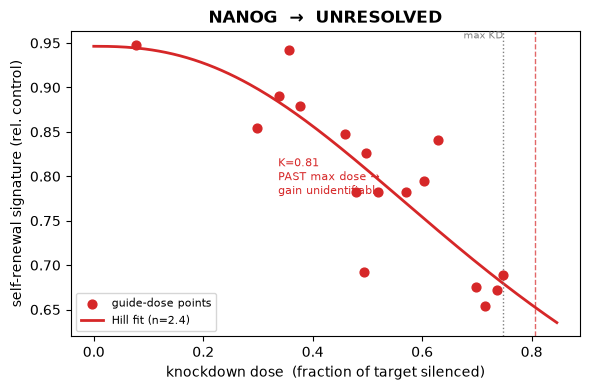

In [5]:
dose, resp = points["NANOG"]
res_nanog = attribute_dose_response(dose, resp, direction="repress", n_boot=1000, seed=0)
f = res_nanog.fit
print(f"CALL: {res_nanog.call.upper()}")
print(f"apparent gain n = {f.n:.2f}  (95% CI {f.ci_n[0]:.2f}-{f.ci_n[1]:.2f})")
print(f"K (threshold)  = {f.k_threshold:.2f}   R2 = {f.r2:.3f}   "
      f"spans_inflection = {f.spans_inflection}   (dose max = {dose.max():.2f})")
print(f"\n{res_nanog.reason}")

fig, ax = plt.subplots(figsize=(6, 4))
plot_fit(ax, "NANOG", res_nanog, "C3")
ax.annotate(f"K={res_nanog.fit.k_threshold:.2f}\nPAST max dose →\ngain unidentifiable",
            (dose.max() * 0.45, 0.78), fontsize=8, color="C3")
plt.tight_layout(); plt.show()


## One call, one honest figure — `nudge.viz`

The two plots above used ad-hoc matplotlib. The shipped **`nudge.viz`** layer renders the
*same* frozen result objects into a single flagship frame with one call — and the honesty
is **structural**: `render()` applies the abstention overlay off each result's own verdict,
so a renderer *cannot* draw NANOG's `unresolved` call as if it were resolved. NANOG's
"K past max dose" bound is drawn as an **open-ended arrow**, never a closed error bar or a
point estimate.

Every figure also ships a standalone `fig.py` + a data sidecar that **regenerates the exact
picture from the fit's output** (no re-fit, deterministic) — the Claude Science provenance
grain. The same one call powers `nudge dose-response … --fig-out fig.png` and (in a later
slice) the MCP `render_figure` tool.


caption:   OCT4 → SWITCH (n≈6.7, R²=0.99) · NANOG → UNRESOLVED (K past max dose → gain unidentifiable)
abstained: True
wrote:     oct4_nanog_flagship.png + oct4_nanog_flagship.py (regenerates the figure) + oct4_nanog_flagship.data.json


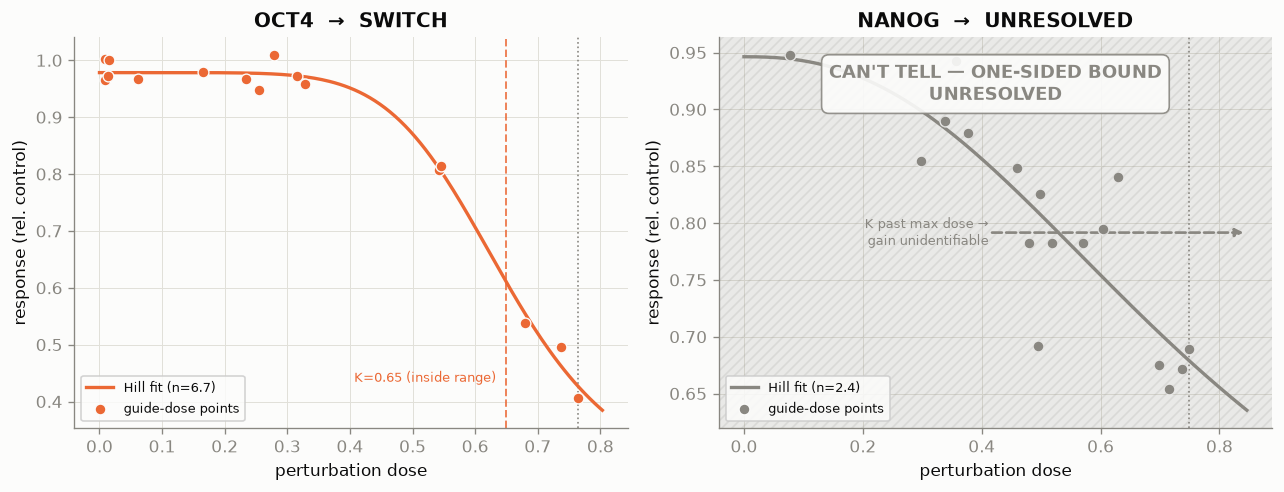

In [6]:
# The one-call figure API — nudge.viz renders the SAME result objects into an honest
# figure, and draws the abstention AS an abstention (no extra plotting code).
import os
import tempfile

import nudge.viz as viz
from IPython.display import Image

fig_path = os.path.join(tempfile.mkdtemp(), "oct4_nanog_flagship.png")
fr = viz.render(
    [("OCT4", res_oct4, *points["OCT4"]), ("NANOG", res_nanog, *points["NANOG"])],
    out=fig_path,
    cli_call="nudge dose-response ESC.h5ad --target OCT4 --fig-out fig.png",
)
print("caption:  ", fr.caption)
print("abstained:", fr.abstained)
print("wrote:    ", os.path.basename(fr.path), "+",
      os.path.basename(fr.code_path), "(regenerates the figure) +",
      os.path.basename(fr.data_path))

# Honesty is load-bearing: the abstention MUST be reported and drawn as an abstention.
assert fr.abstained is True, "NANOG abstains — the figure must carry the caveat"
assert res_nanog.call == "unresolved" and not res_nanog.fit.spans_inflection
Image(fr.path)


## The proof: an `n`-profile likelihood

The decisive, independent test (pure NumPy — no NUDGE classifier in the loop): **fix `n`**
at a grid of values, fit `floor / amp / K` freely at each, and record R².

- If R² **peaks sharply** at one `n` and is poor elsewhere, the data *constrains* the gain
  → resolvable.
- If R² is **flat** across `n`, a graded `n≈1` and a high-threshold switch fit equally well
  → the gain is unidentifiable, and abstaining is the only honest call.


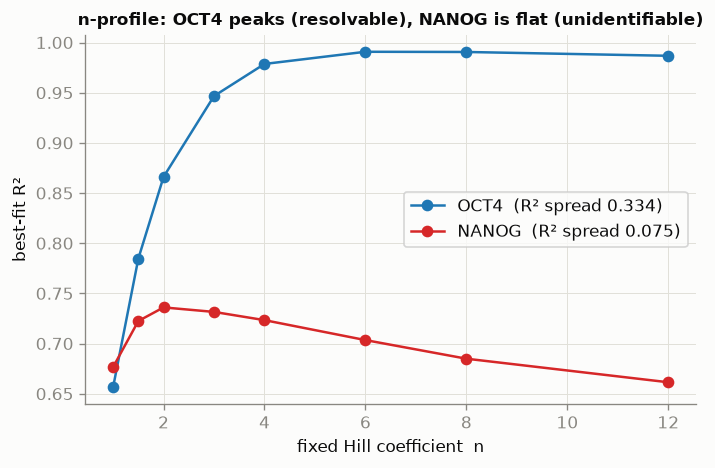

OCT4: R² spread across n = 0.334   → PEAKED → gain resolvable
NANOG: R² spread across n = 0.075   → FLAT → unidentifiable


In [7]:
def n_profile(label):
    dose, resp = points[label]
    tss = np.sum((resp - resp.mean()) ** 2)
    ns = np.array([1.0, 1.5, 2.0, 3.0, 4.0, 6.0, 8.0, 12.0])
    r2s, ks = [], []
    for nf in ns:
        popt, _ = curve_fit(
            lambda d, fl, a, K: hill_repress(d, fl, a, K, nf), dose, resp,
            p0=[resp.min(), resp.max() - resp.min(), 0.5],
            bounds=([0, 0, 0.01], [1.5, 1.5, 3.0]), maxfev=40000,
        )
        r2s.append(1 - np.sum((resp - hill_repress(dose, *popt, nf)) ** 2) / tss)
        ks.append(popt[2])
    return ns, np.array(r2s), np.array(ks)

fig, ax = plt.subplots(figsize=(6, 4))
for label, color in [("OCT4", "C0"), ("NANOG", "C3")]:
    ns, r2s, ks = n_profile(label)
    ax.plot(ns, r2s, "o-", color=color, label=f"{label}  (R² spread {r2s.max()-r2s.min():.3f})")
ax.set_xlabel("fixed Hill coefficient  n"); ax.set_ylabel("best-fit R²")
ax.set_title("n-profile: OCT4 peaks (resolvable), NANOG is flat (unidentifiable)",
             fontsize=10, fontweight="bold")
ax.legend(); plt.tight_layout(); plt.show()

for label in ("OCT4", "NANOG"):
    ns, r2s, ks = n_profile(label)
    verdict = "PEAKED → gain resolvable" if (r2s.max()-r2s.min()) > 0.2 else "FLAT → unidentifiable"
    print(f"{label}: R² spread across n = {r2s.max()-r2s.min():.3f}   → {verdict}")


## The punchline: the classifier caught a human over-reading

An earlier **exploratory** fit (with `K` bounded ≤ 1.0) reported NANOG as *graded*
`n ≈ 2.2`. But look at that fit honestly: `K` **railed against its 1.0 bound** and the
bootstrap `n` CI was **[1.2, 12]** — an under-determined curve whose own uncertainty
screamed non-identifiability. The exploratory script had no classifier; a human eyeballed
the point estimate and called it "graded."

NUDGE's classifier reads the *same* fit and returns **`unresolved`** — because two
independent gates fire: the doses don't span the inflection **and** the `n` CI straddles
the switch/graded line. This is exactly the confident-wrong call the whole project exists
to avoid, here prevented at the source. (Documented as `NUDGE-LIM-007`.)


In [8]:
# Reproduce the old exploratory (K<=1.0-bounded) fit next to NUDGE's honest verdict.
dose, resp = points["NANOG"]
b = ([0, 0, 0.05, 0.3], [1.2, 1.5, 1.0, 12])
popt, _ = curve_fit(hill_repress, dose, resp,
                    p0=[resp.min(), resp.max()-resp.min(), 0.5, 2.0], bounds=b, maxfev=20000)
print("Old exploratory fit (K bounded <= 1.0):")
print(f"   n = {popt[3]:.2f}   K = {popt[2]:.3f}  "
      f"({'RAILED at bound' if popt[2] > 0.98 else 'interior'})   -> a human called this 'graded'")
print(f"\nNUDGE's verdict: {res_nanog.call.upper()}  "
      f"(n CI {res_nanog.fit.ci_n[0]:.1f}-{res_nanog.fit.ci_n[1]:.1f}, K past the dose range)")

print("\n" + "=" * 68)
print(f"{'target':8}{'call':12}{'apparent n':>14}{'K':>8}{'R²':>7}")
print("-" * 68)
for label, res in [("OCT4", res_oct4), ("NANOG", res_nanog)]:
    f = res.fit
    print(f"{label:8}{res.call:12}{f'{f.n:.2f} [{f.ci_n[0]:.1f},{f.ci_n[1]:.1f}]':>14}"
          f"{f.k_threshold:>8.2f}{f.r2:>7.2f}")
print("=" * 68)


Old exploratory fit (K bounded <= 1.0):
   n = 2.20   K = 1.000  (RAILED at bound)   -> a human called this 'graded'

NUDGE's verdict: UNRESOLVED  (n CI 1.6-12.0, K past the dose range)

target  call            apparent n       K     R²
--------------------------------------------------------------------
OCT4    switch      6.74 [4.7,12.0]    0.65   0.99
NANOG   unresolved  2.44 [1.6,12.0]    0.81   0.73


## What NUDGE concluded, honestly

- **OCT4 → `switch`** — a resolved ultrasensitive self-renewal response to its own
  knockdown (apparent `n ≈ 6.7`, R² = 0.99). Consistent with the literature threshold
  behavior of OCT4 dosage (Niwa 2000).
- **NANOG → `unresolved`** — the knockdown series did not span its threshold, so the gain
  is genuinely unidentifiable. NUDGE abstains where a naive fit reports a spuriously
  precise `n`.

**Caveats (carried in the Mechanism Card `NUDGE-METHOD-001` and `NUDGE-LIM-006/007`):** the
reported `n` is an *apparent population gain* (+ CI), not molecular cooperativity; a
nonlinear readout can manufacture apparent ultrasensitivity; guide-level aggregation
averages per-guide effects; the self-renewal signature is a proxy. NUDGE reports what the
data supports — and abstains loudly when it doesn't.

*Run `nudge explain dose_response_attribution` or `nudge explain NUDGE-LIM-007` for the
machine-readable knowledge behind these calls.*
